In [3]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240522

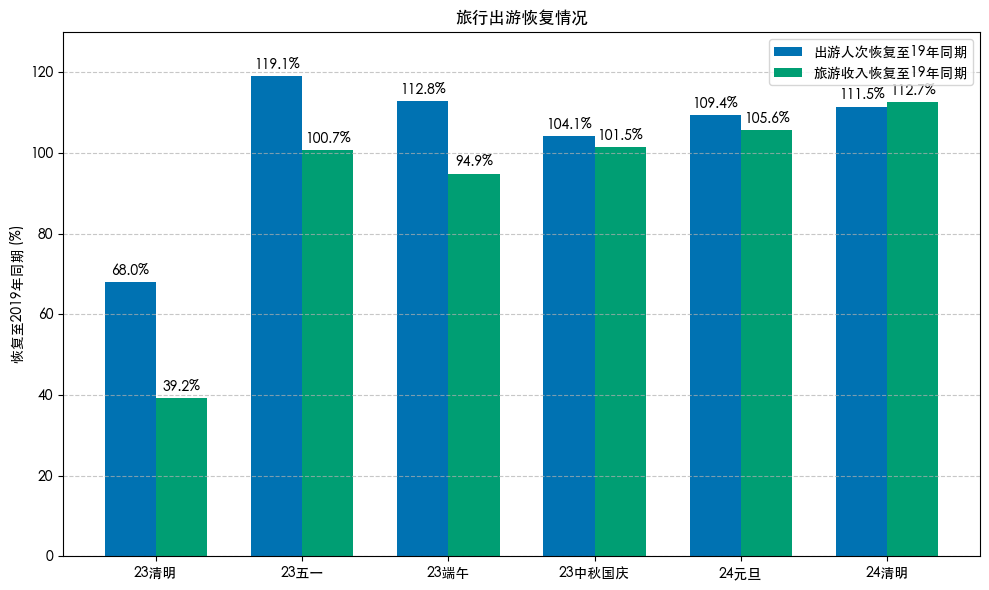

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['23清明', '23五一', '23端午', '23中秋国庆', '24元旦', '24清明']
people_pct = [68.0, 119.1, 112.8, 104.1, 109.4, 111.5]
income_pct = [39.2, 100.7, 94.9, 101.5, 105.6, 112.7]

x = np.arange(len(labels))
width = 0.35

# 颜色设置（蓝绿色系）
colors_people = '#0072B2'  # 蓝色
colors_income = '#009E73'  # 绿色

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, people_pct, width, label='出游人次恢复至19年同期', color=colors_people)
bars2 = ax.bar(x + width/2, income_pct, width, label='旅游收入恢复至19年同期', color=colors_income)

# 添加文本标签
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# 细节设置
ax.set_ylabel('恢复至2019年同期 (%)')
ax.set_title('旅行出游恢复情况')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 130)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


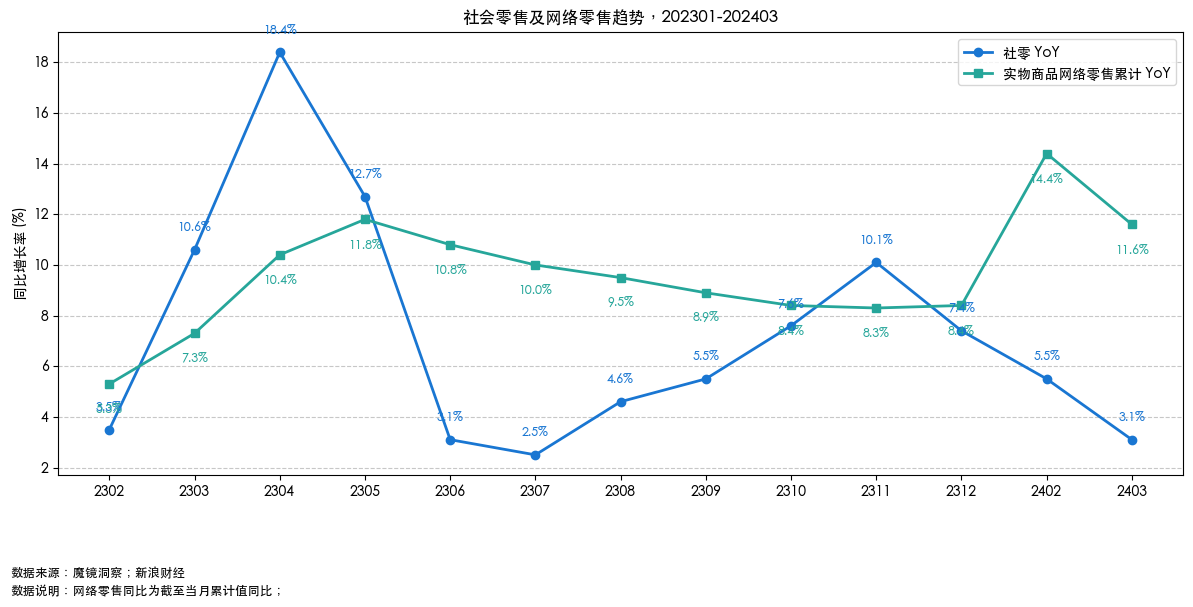

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
months = ['2302', '2303', '2304', '2305', '2306', '2307', '2308', '2309',
          '2310', '2311', '2312', '2402', '2403']
x = np.arange(len(months))

social_retail_yoy = [3.5, 10.6, 18.4, 12.7, 3.1, 2.5, 4.6, 5.5, 7.6, 10.1, 7.4, 5.5, 3.1]
network_retail_yoy = [5.3, 7.3, 10.4, 11.8, 10.8, 10.0, 9.5, 8.9, 8.4, 8.3, 8.4, 14.4, 11.6]

# 画布
plt.figure(figsize=(12, 6))

# 折线图
plt.plot(x, social_retail_yoy, marker='o', label='社零 YoY', color='#1976d2', linewidth=2)
plt.plot(x, network_retail_yoy, marker='s', label='实物商品网络零售累计 YoY', color='#26a69a', linewidth=2)

# 添加数据标签
for i, (y1, y2) in enumerate(zip(social_retail_yoy, network_retail_yoy)):
    plt.text(x[i], y1 + 0.7, f'{y1:.1f}%', ha='center', fontsize=9, color='#1976d2')
    plt.text(x[i], y2 - 1.2, f'{y2:.1f}%', ha='center', fontsize=9, color='#26a69a')

# 设置轴和标题
plt.xticks(x, months)
plt.ylabel('同比增长率 (%)')
plt.title('社会零售及网络零售趋势，202301-202403')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# 添加数据来源和说明
plt.figtext(0.01, 0, "数据来源：魔镜洞察；新浪财经\n数据说明：网络零售同比为截至当月累计值同比；",
            ha='left', fontsize=9, linespacing=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()


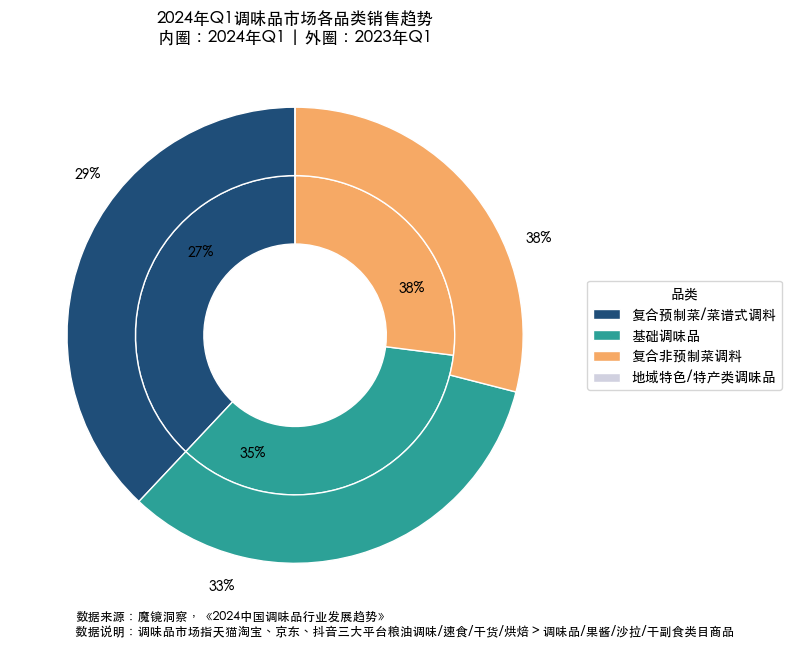

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['复合预制菜/菜谱式调料', '基础调味品', '复合非预制菜调料', '地域特色/特产类调味品']
inner_data = [38, 35, 27, 0]  # 2023 Q1
outer_data = [38, 33, 29, 0]  # 2024 Q1

colors = ['#1f4e79', '#2ca197', '#f6a965', '#d1d1e0']

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', adjustable='box')

# 内圈：2023 Q1
inner_wedges, _ = ax.pie(
    inner_data,
    radius=0.7,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='white')
)

# 外圈：2024 Q1
outer_wedges, _ = ax.pie(
    outer_data,
    radius=1.0,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='white')
)

# 添加百分比标签
def add_labels(wedges, data, radius):
    angle = 90
    total = sum(data)
    for i, (wedge, value) in enumerate(zip(wedges, data)):
        if value == 0:
            continue
        theta = (angle - value / total * 360 / 2) * np.pi / 180
        x = radius * np.cos(theta)
        y = radius * np.sin(theta)
        ax.text(x, y, f'{value}%', ha='center', va='center', fontsize=10)
        angle -= value / total * 360

add_labels(inner_wedges, inner_data, radius=0.55)
add_labels(outer_wedges, outer_data, radius=1.15)

# 添加图例
plt.legend(outer_wedges, labels, title="品类", loc="center left", bbox_to_anchor=(1, 0.5))

# 添加标题
plt.title('2024年Q1调味品市场各品类销售趋势\n内圈：2024年Q1 | 外圈：2023年Q1')

# 添加数据来源说明
plt.figtext(
    0.1, 0.1,
    "数据来源：魔镜洞察，《2024中国调味品行业发展趋势》\n"
    "数据说明：调味品市场指天猫淘宝、京东、抖音三大平台粮油调味/速食/干货/烘焙 > 调味品/果酱/沙拉/干副食类目商品",
    ha='left', fontsize=9
)

plt.tight_layout()
plt.show()


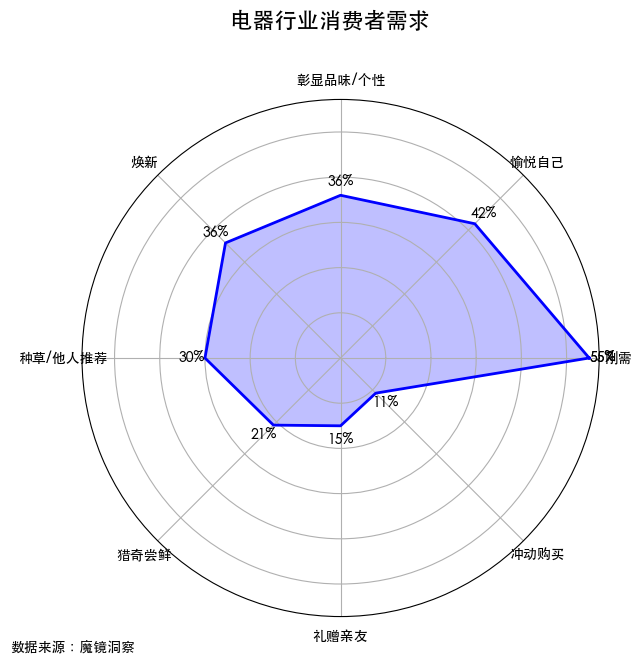

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 标签和数据
labels = ['刚需', '愉悦自己', '彰显品味/个性', '焕新', '种草/他人推荐', '猎奇尝鲜', '礼赠亲友', '冲动购买']
values = [55, 42, 36, 36, 30, 21, 15, 11]

# 处理雷达图的角度
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

# 设置画布
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# 绘图
ax.plot(angles, values, color='blue', linewidth=2)
ax.fill(angles, values, color='blue', alpha=0.25)

# 设置标签
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# 添加数值标签
for angle, value in zip(angles, values):
    ax.text(angle, value + 3, f"{value}%", ha='center', va='center', fontsize=10)

# 添加标题和来源
fig.text(0.5, 1.05, '电器行业消费者需求', ha='center', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=1)  # 增加顶部空间
plt.figtext(0.1, 0.01, "数据来源：魔镜洞察", ha="left", fontsize=10)

plt.tight_layout()
plt.show()
